# Stage 2: NLOS Signal Quality Classifier (CNN)
## Multi-Model Pipeline — Correctable vs Challenging

**Purpose**: Given an NLOS signal (classified by Stage 1), classify its **signal quality** — is it correctable with straightforward ranging error correction, or does it present challenges for Stage 3?

**Two independent measurements from geometric ground truth (`bounce_path_idx`):**

| Measurement | What it checks |
|-------------|---------------|
| **Bounce dominance** | What fraction of CIR energy is concentrated at the known geometric bounce position? |
| **Peak count** | How many prominent peaks exist in the CIR region of interest? |

**Label (mixture rule):**
- **Correctable** (label=0): bounce dominance ≥ 50% AND num_peaks ≤ 2 — signal is clean and dominated by the expected bounce path
- **Challenging** (label=1): either low bounce dominance OR many peaks — multipath contamination makes correction harder

**Why this is NOT circular**: Labels come from geometric ground truth (floor plan → `bounce_path_idx`) and signal morphology (peak count). Features are 128-dim CNN embeddings (learned convolutional representations). These are independent.

**Architecture**: Frozen CNN_Classifier encoder → 128-dim CNN embeddings → Random Forest Classifier

**Pipeline**: Stage 1 (CNN → LOS/NLOS) → **Stage 2 (CNN embeddings → RF → signal quality)** → Stage 3 (→ ranging error correction)

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
import joblib
import os
import re

# ==========================================
# CONFIGURATION
# ==========================================
CONFIG = {
    # ROI alignment (same as Stage 1)
    "search_start": 740,
    "search_end": 810,
    # Peak detection — morphological CIR quality
    "peak_prominence": 0.20,
    "peak_min_distance": 5,
    "dominant_path_max_peaks": 2,
    # Geometric bounce dominance (amplitude ratio)
    "bounce_search_window": 3,
    "dominance_threshold": 0.50,
    # Random Forest
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    # Split
    "test_ratio": 0.30,
    "seed": 42,
}

np.random.seed(CONFIG["seed"])
print(f"Config: {CONFIG}")
print(f"\nLabel strategy: MIXTURE (geometric + morphological)")
print(f"  Criterion 1: bounce dominance (amplitude ratio) >= {CONFIG['dominance_threshold']:.0%}")
print(f"  Criterion 2: num_peaks <= {CONFIG['dominant_path_max_peaks']}")
print(f"  Correctable (0): BOTH conditions met")
print(f"  Challenging (1): either condition violated")
print(f"  Model input:   128-dim CNN embeddings → RF classifier")

Config: {'search_start': 740, 'search_end': 810, 'peak_prominence': 0.2, 'peak_min_distance': 5, 'dominant_path_max_peaks': 2, 'bounce_search_window': 3, 'dominance_threshold': 0.5, 'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'test_ratio': 0.3, 'seed': 42}

Label strategy: MIXTURE (geometric + morphological)
  Criterion 1: bounce dominance (amplitude ratio) >= 50%
  Criterion 2: num_peaks <= 2
  Correctable (0): BOTH conditions met
  Challenging (1): either condition violated
  Model input:   128-dim CNN embeddings → RF classifier


---
## Section 2: Data Loading & Mixture Quality Labeling

1. Load NLOS samples from the combined dataset
2. **Mixture labeling** from geometric ground truth + signal morphology:
   - **Bounce dominance**: fraction of CIR energy at the known `bounce_path_idx` (from TX→reflector→RX floor plan geometry)
   - **Peak count**: number of prominent peaks in the CIR ROI
   - Correctable = bounce dominance ≥ 50% AND num_peaks ≤ 2
   - Challenging = otherwise

**Note**: All NLOS data is single-bounce by geometry (TX → wall → RX). The two measurements capture different aspects of signal quality — geometric (energy concentration) and morphological (multipath complexity).

In [14]:
# ==========================================
# ROI ALIGNMENT (reused from Stage 1)
# ==========================================
def get_roi_alignment(sig, search_start=CONFIG["search_start"],
                      search_end=CONFIG["search_end"]):
    """Find leading edge by backtracking from peak."""
    region = sig[search_start:search_end]
    if len(region) == 0:
        return np.argmax(sig)

    peak_local = np.argmax(region)
    peak_idx = search_start + peak_local
    peak_val = sig[peak_idx]

    noise_section = sig[:search_start]
    if len(noise_section) > 10:
        noise_mean = np.mean(noise_section)
        noise_std = np.std(noise_section)
        threshold = max(noise_mean + 3 * noise_std, 0.05 * peak_val)
    else:
        threshold = 0.05 * peak_val

    leading_edge = peak_idx
    for i in range(peak_idx, max(search_start - 20, 0), -1):
        if sig[i] < threshold:
            leading_edge = i + 1
            break

    return leading_edge


# ==========================================
# COUNT PEAKS IN CIR ROI
# ==========================================
def count_peaks_in_roi(sig, leading_edge, config=CONFIG):
    """Count prominent peaks in CIR ROI (120 samples from leading edge)."""
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    if len(roi) == 0 or np.max(roi) == 0:
        return 0
    roi_norm = roi / np.max(roi)
    peaks, _ = find_peaks(
        roi_norm,
        prominence=config["peak_prominence"],
        distance=config["peak_min_distance"]
    )
    return len(peaks)


# ==========================================
# GEOMETRIC BOUNCE DOMINANCE (AMPLITUDE RATIO)
# ==========================================
def compute_bounce_dominance(sig, leading_edge, bounce_path_idx,
                              window=CONFIG["bounce_search_window"]):
    """
    Amplitude ratio: peak amplitude near bounce position / strongest peak in ROI.
    Returns 0-1. High value = bounce peak is the dominant peak.
    Not affected by ROI size or tail energy dilution.
    """
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]

    if len(roi) == 0 or np.max(roi) == 0:
        return 0.0

    strongest_amp = float(np.max(roi))

    bounce_idx = int(round(bounce_path_idx))
    b_start = max(0, bounce_idx - window)
    b_end = min(len(sig), bounce_idx + window + 1)

    if b_start >= b_end:
        return 0.0

    bounce_amp = float(np.max(sig[b_start:b_end]))
    return bounce_amp / strongest_amp


# ==========================================
# STRONGEST PEAK POWER IN ROI
# ==========================================
def get_strongest_peak_power(sig, leading_edge):
    """Max CIR amplitude in ROI after RXPACC normalization."""
    roi_start = max(0, leading_edge - 5)
    roi_end = min(len(sig), leading_edge + 120)
    roi = sig[roi_start:roi_end]
    if len(roi) == 0:
        return 0.0
    return float(np.max(roi))


# ==========================================
# LOAD NLOS DATA + MIXTURE LABELS
# ==========================================
def load_nlos_features(filepath="../dataset/channels/combined_uwb_dataset.csv"):
    """
    Load NLOS samples and compute mixture quality labels.
    Correctable: bounce dominance (amplitude ratio) >= threshold AND num_peaks <= max_peaks.
    Challenging: otherwise.
    """
    print(f"Loading: {filepath}")
    df = pd.read_csv(filepath)

    nlos_df = df[df["Label"] == 1].reset_index(drop=True)
    print(f"  Total samples: {len(df)}, NLOS samples: {len(nlos_df)}")

    cir_cols = sorted(
        [c for c in df.columns if c.startswith('CIR')],
        key=lambda x: int(x.replace('CIR', ''))
    )

    raw_sigs = []
    leading_edges = []
    num_peaks_list = []
    bounce_dom_list = []
    strongest_peak_power_list = []

    for idx, row in nlos_df.iterrows():
        sig = pd.to_numeric(row[cir_cols], errors='coerce').fillna(0).astype(float).values

        rxpacc_col = 'RXPACC' if 'RXPACC' in row.index else 'RX_PACC'
        rxpacc = float(row.get(rxpacc_col, 128.0))
        if rxpacc > 0:
            sig = sig / rxpacc

        le = get_roi_alignment(sig)
        raw_sigs.append(sig)
        leading_edges.append(le)

        num_peaks_list.append(count_peaks_in_roi(sig, le))

        bpi = float(row.get('bounce_path_idx', np.nan))
        if np.isnan(bpi):
            bounce_dom_list.append(0.0)
        else:
            bounce_dom_list.append(compute_bounce_dominance(sig, le, bpi))

        strongest_peak_power_list.append(get_strongest_peak_power(sig, le))

    num_peaks = np.array(num_peaks_list, dtype=int)
    bounce_dominance = np.array(bounce_dom_list, dtype=float)
    strongest_peak_power = np.array(strongest_peak_power_list, dtype=float)

    dom_thresh = CONFIG["dominance_threshold"]
    peak_thresh = CONFIG["dominant_path_max_peaks"]
    is_correctable = (bounce_dominance >= dom_thresh) & (num_peaks <= peak_thresh)
    quality_labels = np.where(is_correctable, 0, 1).astype(int)

    n_correctable = int(np.sum(quality_labels == 0))
    n_challenging = int(np.sum(quality_labels == 1))

    print(f"\n  Mixture labeling (amplitude ratio >= {dom_thresh:.0%} AND peaks <= {peak_thresh}):")
    print(f"    {'─' * 50}")
    print(f"    Correctable (clean bounce):     {n_correctable} ({100*n_correctable/len(quality_labels):.1f}%)")
    print(f"    Challenging (multipath/noisy):   {n_challenging} ({100*n_challenging/len(quality_labels):.1f}%)")
    print(f"    {'─' * 50}")
    print(f"    Bounce dominance stats — mean: {bounce_dominance.mean():.3f}, "
          f"median: {np.median(bounce_dominance):.3f}")
    print(f"    Peak count stats — mean: {num_peaks.mean():.2f}, "
          f"max: {num_peaks.max()}")
    print(f"    Strongest peak power stats — mean: {strongest_peak_power.mean():.4f}, "
          f"min: {strongest_peak_power.min():.4f}, max: {strongest_peak_power.max():.4f}")

    return (np.array(raw_sigs), np.array(leading_edges), nlos_df,
            quality_labels, num_peaks, bounce_dominance, strongest_peak_power)


raw_sigs, leading_edges, nlos_df, quality_labels, num_peaks, bounce_dominance, strongest_peak_power = load_nlos_features()

Loading: ../dataset/channels/combined_uwb_dataset.csv
  Total samples: 3600, NLOS samples: 1800

  Mixture labeling (amplitude ratio >= 50% AND peaks <= 2):
    ──────────────────────────────────────────────────
    Correctable (clean bounce):     506 (28.1%)
    Challenging (multipath/noisy):   1294 (71.9%)
    ──────────────────────────────────────────────────
    Bounce dominance stats — mean: 0.778, median: 0.890
    Peak count stats — mean: 4.71, max: 12
    Strongest peak power stats — mean: 35.2407, min: 5.3226, max: 65.2119


---
## Section 2b: Mixture Quality Labeling — Geometric + Morphological

**Ground-truth labeling** uses two independent measurements:

| Measurement | What it checks |
|-------------|---------------|
| **Bounce dominance** | Amplitude ratio: bounce peak / strongest peak in ROI |
| **Peak count** | How many prominent peaks exist in the CIR region of interest? |

**Mixture rule**: Correctable (0) = bounce dominance ≥ 50% AND peaks ≤ 2. Challenging (1) = either condition violated.

These labels come from geometric ground truth + signal morphology, NOT from the CNN embeddings the RF will train on.

Mixture labeling (amplitude ratio >= 50% AND peaks <= 2):
  Correctable: 506 (28.1%)
  Challenging: 1294 (71.9%)


C:\Users\preca\AppData\Local\Temp\ipykernel_15040\3912780407.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=unique_groups, patch_artist=True)


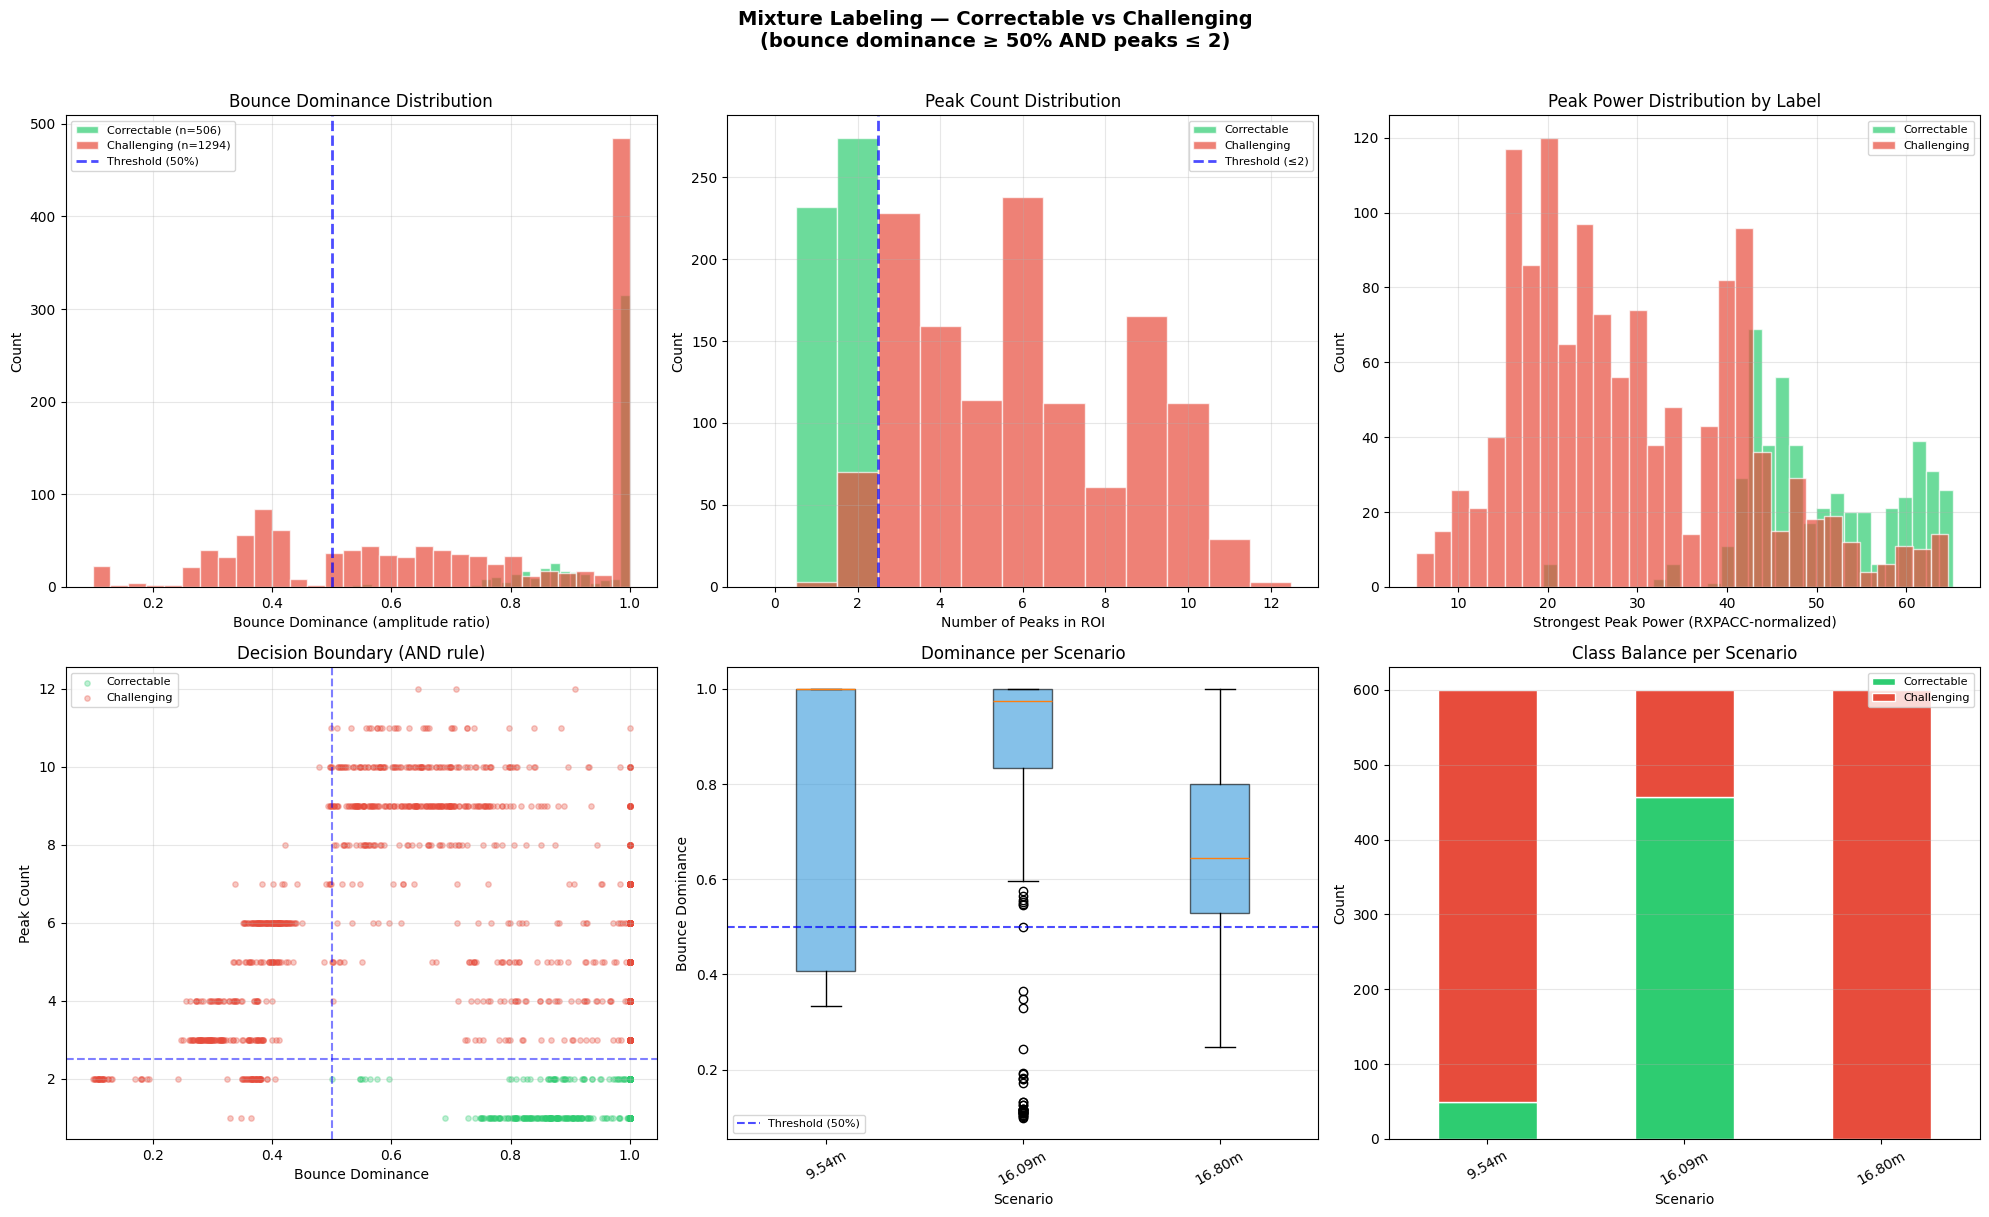

In [15]:
# ==========================================
# MIXTURE LABELING VISUALIZATION
# ==========================================
dom_thresh = CONFIG["dominance_threshold"]
peak_thresh = CONFIG["dominant_path_max_peaks"]
n_correctable = int(np.sum(quality_labels == 0))
n_challenging = int(np.sum(quality_labels == 1))

print(f"Mixture labeling (amplitude ratio >= {dom_thresh:.0%} AND peaks <= {peak_thresh}):")
print(f"  Correctable: {n_correctable} ({100*n_correctable/len(quality_labels):.1f}%)")
print(f"  Challenging: {n_challenging} ({100*n_challenging/len(quality_labels):.1f}%)")

fig, axs = plt.subplots(2, 3, figsize=(20, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

correctable_mask = quality_labels == 0
challenging_mask = quality_labels == 1

# â”€â”€â”€ 1. Bounce dominance histogram â”€â”€â”€
ax = axs[0, 0]
if correctable_mask.sum() > 0:
    ax.hist(bounce_dominance[correctable_mask], bins=30, color='#2ecc71', alpha=0.7,
            label=f'Correctable (n={n_correctable})', edgecolor='white')
if challenging_mask.sum() > 0:
    ax.hist(bounce_dominance[challenging_mask], bins=30, color='#e74c3c', alpha=0.7,
            label=f'Challenging (n={n_challenging})', edgecolor='white')
ax.axvline(dom_thresh, color='blue', ls='--', lw=2, alpha=0.7,
           label=f'Threshold ({dom_thresh:.0%})')
ax.set_xlabel('Bounce Dominance (amplitude ratio)')
ax.set_ylabel('Count')
ax.set_title('Bounce Dominance Distribution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# â”€â”€â”€ 2. Peak count histogram â”€â”€â”€
ax = axs[0, 1]
max_peaks = int(num_peaks.max())
bins_peaks = np.arange(-0.5, max_peaks + 1.5, 1)
if correctable_mask.sum() > 0:
    ax.hist(num_peaks[correctable_mask], bins=bins_peaks, color='#2ecc71', alpha=0.7,
            label='Correctable', edgecolor='white')
if challenging_mask.sum() > 0:
    ax.hist(num_peaks[challenging_mask], bins=bins_peaks, color='#e74c3c', alpha=0.7,
            label='Challenging', edgecolor='white')
ax.axvline(peak_thresh + 0.5, color='blue', ls='--', lw=2, alpha=0.7,
           label=f'Threshold (≤{peak_thresh})')
ax.set_xlabel('Number of Peaks in ROI')
ax.set_ylabel('Count')
ax.set_title('Peak Count Distribution')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# â”€â”€â”€ 3. Strongest peak power by label â”€â”€â”€
ax = axs[0, 2]
if correctable_mask.sum() > 0:
    ax.hist(strongest_peak_power[correctable_mask], bins=30, color='#2ecc71', alpha=0.7,
            label='Correctable', edgecolor='white')
if challenging_mask.sum() > 0:
    ax.hist(strongest_peak_power[challenging_mask], bins=30, color='#e74c3c', alpha=0.7,
            label='Challenging', edgecolor='white')
ax.set_xlabel('Strongest Peak Power (RXPACC-normalized)')
ax.set_ylabel('Count')
ax.set_title('Peak Power Distribution by Label')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# â”€â”€â”€ 4. Scatter: dominance vs peak count â”€â”€â”€
ax = axs[1, 0]
if correctable_mask.sum() > 0:
    ax.scatter(bounce_dominance[correctable_mask], num_peaks[correctable_mask],
               c='#2ecc71', alpha=0.3, s=15, label='Correctable')
if challenging_mask.sum() > 0:
    ax.scatter(bounce_dominance[challenging_mask], num_peaks[challenging_mask],
               c='#e74c3c', alpha=0.3, s=15, label='Challenging')
ax.axvline(dom_thresh, color='blue', ls='--', lw=1.5, alpha=0.5)
ax.axhline(peak_thresh + 0.5, color='blue', ls='--', lw=1.5, alpha=0.5)
ax.set_xlabel('Bounce Dominance')
ax.set_ylabel('Peak Count')
ax.set_title('Decision Boundary (AND rule)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# â”€â”€â”€ 5. Per-scenario boxplot â”€â”€â”€
ax = axs[1, 1]
groups = np.array([
    re.search(r'([\d.]+)m_nlos', str(sf)).group(1) + 'm'
    if re.search(r'([\d.]+)m_nlos', str(sf)) else 'unknown'
    for sf in nlos_df['Source_File'].values
])
unique_groups = sorted(set(groups), key=lambda x: float(x.replace('m', '')))
box_data = [bounce_dominance[groups == g] for g in unique_groups]
bp = ax.boxplot(box_data, labels=unique_groups, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
    patch.set_alpha(0.6)
ax.axhline(dom_thresh, color='blue', ls='--', lw=1.5, alpha=0.7,
           label=f'Threshold ({dom_thresh:.0%})')
ax.set_xlabel('Scenario')
ax.set_ylabel('Bounce Dominance')
ax.set_title('Dominance per Scenario')
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3, axis='y')

# â”€â”€â”€ 6. Class balance per scenario â”€â”€â”€
ax = axs[1, 2]
scenario_df = pd.DataFrame({'scenario': groups, 'label': quality_labels})
balance = scenario_df.groupby(['scenario', 'label']).size().unstack(fill_value=0)
for col_label in [0, 1]:
    if col_label not in balance.columns:
        balance[col_label] = 0
balance = balance.rename(columns={0: 'Correctable', 1: 'Challenging'})
balance = balance.reindex(unique_groups)
balance[['Correctable', 'Challenging']].plot(
    kind='bar', stacked=True, color=['#2ecc71', '#e74c3c'], ax=ax, edgecolor='white')
ax.set_xlabel('Scenario')
ax.set_ylabel('Count')
ax.set_title('Class Balance per Scenario')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(f"Mixture Labeling — Correctable vs Challenging\n"
             f"(bounce dominance ≥ {dom_thresh:.0%} AND peaks ≤ {peak_thresh})",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 3: Shared CNN Encoder — Embedding Extraction

The Stage 1 **CNN_Classifier** processes raw CIR sequences through 1D convolutional layers with batch normalization, then applies global average pooling to produce **128-dim CNN embeddings**.

We **freeze** the trained encoder and extract embeddings for each NLOS sample. These embeddings are passed to Stage 2 RF and Stage 3 for ranging error correction.

**Key**: The CNN captures spatial/frequency patterns in the CIR waveform via learned convolutional filters, complementary to the LNN's temporal ODE dynamics.

In [16]:
import torch
import torch.nn as nn


class CNN_Classifier(nn.Module):
    """1D-CNN encoder for CIR classification (Stage 1 architecture)."""

    def __init__(self, input_channels=1, embedding_size=128, dropout=0.4):
        super().__init__()
        self.embedding_size = embedding_size

        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=5, padding=2),             # (B,1,60) -> (B,16,60)
            nn.BatchNorm1d(16), nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2, stride=2),  # (B,16,60) -> (B,32,30)
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 128, kernel_size=3, padding=1, stride=2), # (B,32,30) -> (B,128,15)
            nn.BatchNorm1d(128), nn.ReLU(),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)  # (B,128,15) -> (B,128,1)

        self.classifier = nn.Sequential(
            nn.Linear(128, 32),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def _encode_cir(self, x):
        """(B, 1, 60) -> (B, 128) CNN embedding."""
        features = self.encoder(x)
        return self.gap(features).squeeze(-1)

    def forward(self, x, return_dynamics=False):
        cnn_embed = self._encode_cir(x)
        pred = self.classifier(cnn_embed)
        if return_dynamics:
            features = self.encoder(x)
            return pred, features
        return pred

    def embed(self, x):
        """Return 128-dim embedding for Stage 2/3."""
        return self._encode_cir(x)

In [17]:
# ==========================================
# LOAD FROZEN STAGE 1 ENCODER & EXTRACT EMBEDDINGS
# ==========================================
# Load Stage 1 config
_saved = torch.load("stage1_cnn_config.pt", map_location="cpu", weights_only=False)
STAGE1_CONFIG = _saved["config"]
print("STAGE1_CONFIG loaded from stage1_cnn_config.pt")
print(STAGE1_CONFIG)

EMBEDDING_DIM = STAGE1_CONFIG["embedding_size"]  # 128
EMBEDDING_NAMES = [f'CNN_h{i}' for i in range(EMBEDDING_DIM)]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def preprocess_cir_for_cnn(sig, leading_edge):
    """Convert a single RXPACC-normalized CIR + leading edge to 60-sample window."""
    PRE = STAGE1_CONFIG['pre_crop']
    TOTAL = STAGE1_CONFIG['total_len']
    start = max(0, leading_edge - PRE)
    end = start + TOTAL
    if end > len(sig):
        end = len(sig)
        start = max(0, end - TOTAL)
    crop = sig[start:end]
    if len(crop) < TOTAL:
        crop = np.pad(crop, (0, TOTAL - len(crop)), mode='constant')
    local_min, local_max = np.min(crop), np.max(crop)
    rng = local_max - local_min
    crop = (crop - local_min) / rng if rng > 0 else np.zeros(TOTAL)
    return crop


# Load frozen Stage 1 encoder (CNN_Classifier)
cnn_encoder = CNN_Classifier(
    input_channels=STAGE1_CONFIG["input_channels"],
    embedding_size=STAGE1_CONFIG["embedding_size"],
    dropout=STAGE1_CONFIG["dropout"],
).to(device)

checkpoint_path = 'stage1_cnn_best.pt'
cnn_encoder.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
cnn_encoder.eval()
for param in cnn_encoder.parameters():
    param.requires_grad = False

print(f"\nLoaded frozen Stage 1 encoder from {checkpoint_path}")
print(f"  Architecture: CNN_Classifier (Conv1d → BN → ReLU × 3 → GAP)")
print(f"  Device: {device}")
print(f"  Parameters: {sum(p.numel() for p in cnn_encoder.parameters()):,} (all frozen)")
print(f"  Embedding dim: {EMBEDDING_DIM} (global average pooled)")
print(f"  Pooling: AdaptiveAvgPool1d (128 channels → 128-dim)")

# Extract 128-dim CNN embeddings for all NLOS samples
print(f"\nExtracting {EMBEDDING_DIM}-dim embeddings for {len(nlos_df)} NLOS samples...")

cir_sequences = []
for i in range(len(raw_sigs)):
    crop = preprocess_cir_for_cnn(raw_sigs[i], leading_edges[i])
    cir_sequences.append(crop)

# CNN expects (B, 1, 60) — channels first
cir_tensor = torch.tensor(
    np.array(cir_sequences).reshape(-1, 1, STAGE1_CONFIG['total_len']),
    dtype=torch.float32
).to(device)

all_embeddings = []
with torch.no_grad():
    for i in range(0, len(cir_tensor), 256):
        batch_cir = cir_tensor[i:i+256]
        emb = cnn_encoder.embed(batch_cir)  # (batch, 128)
        all_embeddings.append(emb.cpu().numpy())

embeddings = np.vstack(all_embeddings)
print(f"  Embeddings shape: {embeddings.shape}")
print(f"  Mean: {embeddings.mean():.4f}, Std: {embeddings.std():.4f}")

STAGE1_CONFIG loaded from stage1_cnn_config.pt
{'pre_crop': 10, 'post_crop': 50, 'total_len': 60, 'search_start': 740, 'search_end': 810, 'embedding_size': 128, 'input_channels': 1, 'dropout': 0.4, 'batch_size': 64, 'max_epochs': 50, 'lr': 0.001, 'weight_decay': 0.0001, 'warmup_epochs': 3, 'patience': 10, 'grad_clip': 1.0, 'val_ratio': 0.15, 'test_ratio': 0.15, 'seed': 42}

Loaded frozen Stage 1 encoder from stage1_cnn_best.pt
  Architecture: CNN_Classifier (Conv1d → BN → ReLU × 3 → GAP)
  Device: cuda
  Parameters: 19,617 (all frozen)
  Embedding dim: 128 (global average pooled)
  Pooling: AdaptiveAvgPool1d (128 channels → 128-dim)

Extracting 128-dim embeddings for 1800 NLOS samples...
  Embeddings shape: (1800, 128)
  Mean: 0.5032, Std: 0.2913


---
## Section 4: CIR Waveform Examples

Compare **Correctable** (clean, bounce-dominated, few peaks) vs **Challenging** (dispersed energy or complex morphology) CIR waveforms.

Red vertical line marks the geometric bounce position (`bounce_path_idx`). Shaded red region shows the ±3 search window used for bounce dominance computation.

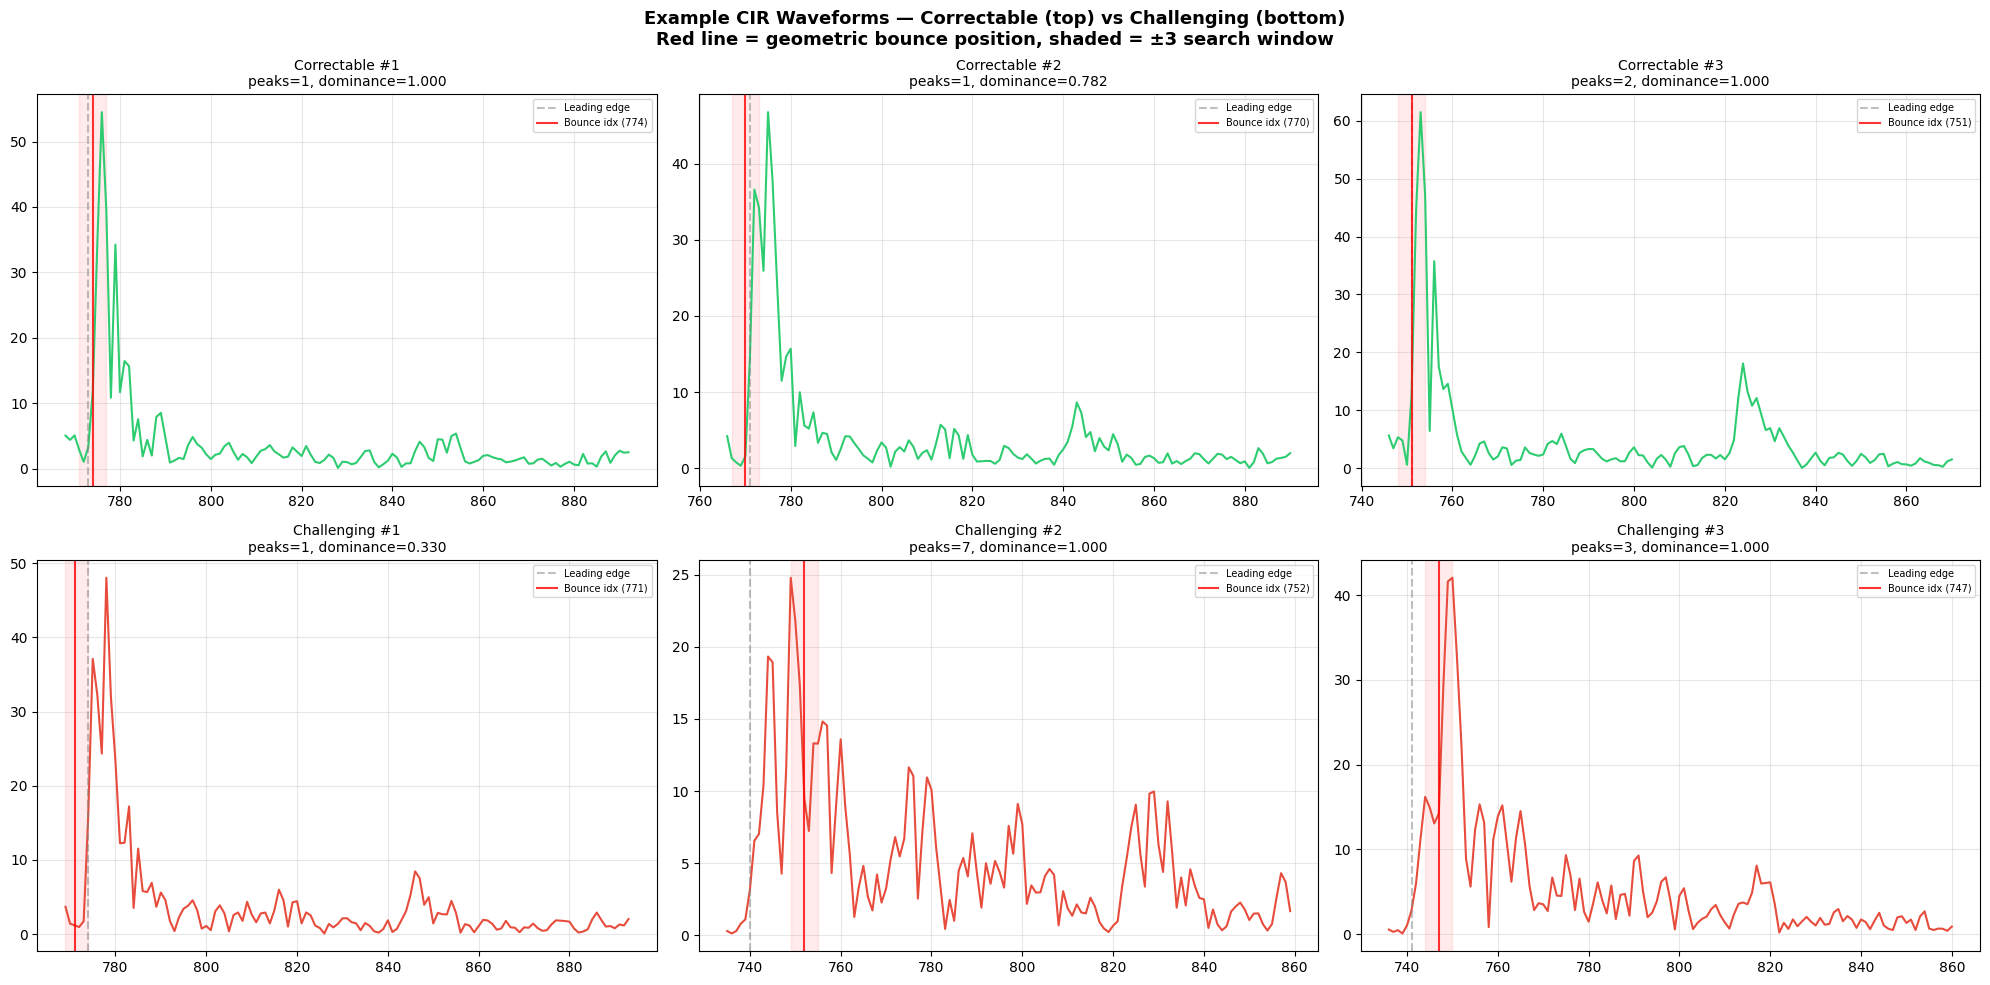

In [18]:
# ==========================================
# EXAMPLE CIR WAVEFORMS (Correctable vs Challenging)
# ==========================================
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
plt.subplots_adjust(hspace=0.45, wspace=0.3)

W = CONFIG['bounce_search_window']
correctable_idx = np.where(quality_labels == 0)[0]
challenging_idx = np.where(quality_labels == 1)[0]

# Show 3 correctable examples (spread across dataset for diversity)
for col in range(3):
    if col >= len(correctable_idx):
        axs[0, col].axis('off')
        continue
    step = max(1, len(correctable_idx) // 3)
    idx = correctable_idx[min(col * step, len(correctable_idx) - 1)]
    sig = raw_sigs[idx]
    le = leading_edges[idx]
    bpi = float(nlos_df.iloc[idx].get('bounce_path_idx', np.nan))
    bounce_idx = int(round(bpi)) if not np.isnan(bpi) else None

    roi_start = max(0, le - 5)
    roi_end = min(len(sig), le + 120)
    x_range = np.arange(roi_start, roi_end)

    ax = axs[0, col]
    ax.plot(x_range, sig[roi_start:roi_end], color='#2ecc71', lw=1.5)
    ax.axvline(le, color='gray', ls='--', alpha=0.5, label='Leading edge')
    if bounce_idx is not None:
        ax.axvline(bounce_idx, color='red', ls='-', lw=1.5, alpha=0.8,
                   label=f'Bounce idx ({bounce_idx})')
        ax.axvspan(max(roi_start, bounce_idx - W), min(roi_end, bounce_idx + W),
                   color='red', alpha=0.08)
    ax.set_title(f"Correctable #{col+1}\n"
                 f"peaks={num_peaks[idx]}, dominance={bounce_dominance[idx]:.3f}",
                 fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# Show 3 challenging examples (spread across dataset)
for col in range(3):
    if col >= len(challenging_idx):
        axs[1, col].axis('off')
        continue
    step = max(1, len(challenging_idx) // 3)
    idx = challenging_idx[min(col * step, len(challenging_idx) - 1)]
    sig = raw_sigs[idx]
    le = leading_edges[idx]
    bpi = float(nlos_df.iloc[idx].get('bounce_path_idx', np.nan))
    bounce_idx = int(round(bpi)) if not np.isnan(bpi) else None

    roi_start = max(0, le - 5)
    roi_end = min(len(sig), le + 120)
    x_range = np.arange(roi_start, roi_end)

    ax = axs[1, col]
    ax.plot(x_range, sig[roi_start:roi_end], color='#e74c3c', lw=1.5)
    ax.axvline(le, color='gray', ls='--', alpha=0.5, label='Leading edge')
    if bounce_idx is not None:
        ax.axvline(bounce_idx, color='red', ls='-', lw=1.5, alpha=0.8,
                   label=f'Bounce idx ({bounce_idx})')
        ax.axvspan(max(roi_start, bounce_idx - W), min(roi_end, bounce_idx + W),
                   color='red', alpha=0.08)
    ax.set_title(f"Challenging #{col+1}\n"
                 f"peaks={num_peaks[idx]}, dominance={bounce_dominance[idx]:.3f}",
                 fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Example CIR Waveforms — Correctable (top) vs Challenging (bottom)\n"
             f"Red line = geometric bounce position, shaded = ±{W} search window",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 4b: Single-Bounce NLOS Physics — Annotated CIR

Each NLOS scenario is a **single-bounce** reflection: TX → wall/pillar → RX.

The CIR reveals two key positions:
- **`los_path_idx`** (blue dashed): Where the **direct path** would arrive if unobstructed (distance `d_direct`)
- **`bounce_path_idx`** (red solid): Where the **reflected path** actually arrives (distance `d_bounce`)

The gap between them is the **NLOS ranging bias** — the extra path length from the bounce.

This plot shows one representative sample from each of the 5 NLOS scenarios, with both markers and the delay annotated.

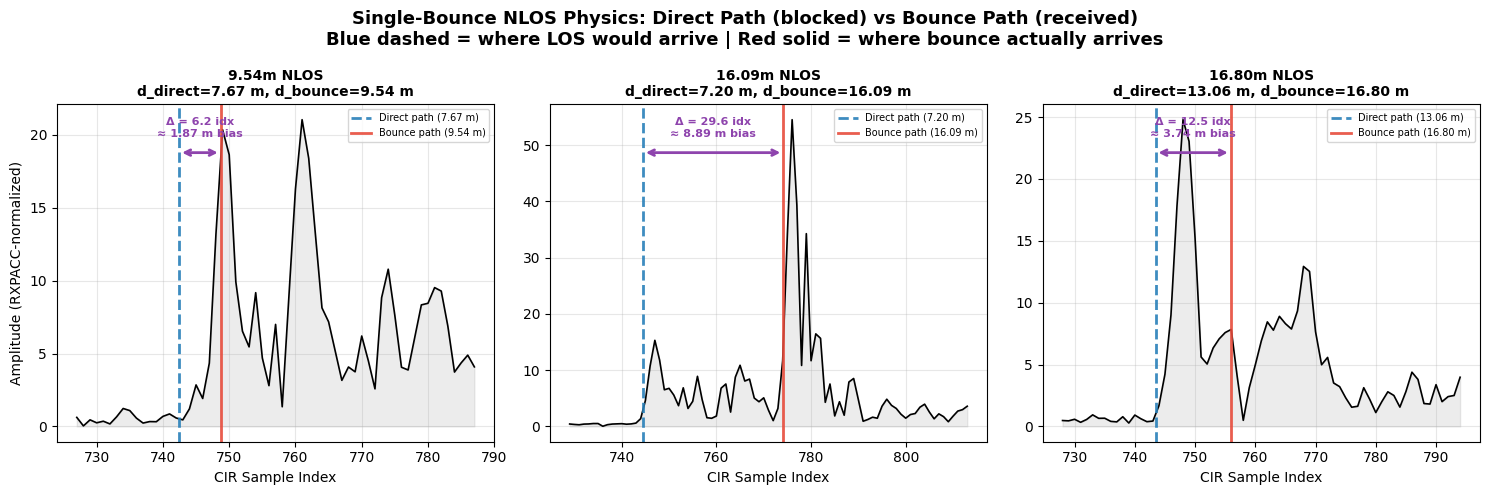


NLOS Scenario Summary:
Scenario     d_direct (m)   d_bounce (m)   Bias (m)   Delay (idx) 
â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
9.54m        7.668          9.54           1.872      6.2         
16.09m       7.201          16.09          8.889      29.6        
16.80m       13.060         16.80          3.740      12.5        


In [19]:
# ==========================================
# SINGLE-BOUNCE NLOS PHYSICS — ANNOTATED CIR
# ==========================================
# One representative sample per NLOS scenario, showing both LOS and bounce path positions

M_PER_INDEX = 0.3003  # ~1.0016 ns/sample × c

# Group by scenario
scenarios = {}
for i, row in nlos_df.iterrows():
    sf = str(row['Source_File'])
    match = re.search(r'([\d.]+)m_nlos', sf)
    if match:
        key = match.group(1) + 'm'
        local_idx = i - nlos_df.index[0]  # convert to 0-based index into raw_sigs
        if key not in scenarios:
            scenarios[key] = local_idx

scenario_keys = sorted(scenarios.keys(), key=lambda k: float(k.replace('m', '')))
n_scenarios = len(scenario_keys)

fig, axs = plt.subplots(1, n_scenarios, figsize=(5 * n_scenarios, 5), sharey=False)
if n_scenarios == 1:
    axs = [axs]

for col, key in enumerate(scenario_keys):
    idx = scenarios[key]
    row = nlos_df.iloc[idx]
    sig = raw_sigs[idx]
    le = leading_edges[idx]

    los_idx = float(row['los_path_idx'])
    bounce_idx = float(row['bounce_path_idx'])
    d_direct = float(row['d_direct'])
    d_bounce = float(row['d_bounce'])
    bias_m = d_bounce - d_direct
    delay_samples = bounce_idx - los_idx

    # Show a wider window to capture both markers
    view_start = max(0, int(los_idx) - 15)
    view_end = min(len(sig), int(bounce_idx) + 40)
    x_range = np.arange(view_start, view_end)

    ax = axs[col]
    # CIR waveform
    ax.fill_between(x_range, sig[view_start:view_end], alpha=0.15, color='gray')
    ax.plot(x_range, sig[view_start:view_end], color='k', lw=1.2)

    # LOS path position (direct — would arrive here if unobstructed)
    ax.axvline(los_idx, color='#2980b9', ls='--', lw=2, alpha=0.9,
               label=f'Direct path ({d_direct:.2f} m)')

    # Bounce path position (reflected — actually arrives here)
    ax.axvline(bounce_idx, color='#e74c3c', ls='-', lw=2, alpha=0.9,
               label=f'Bounce path ({d_bounce:.2f} m)')

    # Annotate the delay gap
    y_arrow = ax.get_ylim()[1] * 0.85
    ax.annotate('', xy=(bounce_idx, y_arrow), xytext=(los_idx, y_arrow),
                arrowprops=dict(arrowstyle='<->', color='#8e44ad', lw=2))
    mid_x = (los_idx + bounce_idx) / 2
    ax.text(mid_x, y_arrow * 1.05,
            f'Δ = {delay_samples:.1f} idx\n≈ {bias_m:.2f} m bias',
            ha='center', va='bottom', fontsize=8, fontweight='bold', color='#8e44ad')

    ax.set_title(f'{key} NLOS\n'
                 f'd_direct={d_direct:.2f} m, d_bounce={d_bounce:.2f} m',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('CIR Sample Index')
    if col == 0:
        ax.set_ylabel('Amplitude (RXPACC-normalized)')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

fig.suptitle('Single-Bounce NLOS Physics: Direct Path (blocked) vs Bounce Path (received)\n'
             'Blue dashed = where LOS would arrive | Red solid = where bounce actually arrives',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print scenario summary
print("\nNLOS Scenario Summary:")
print(f"{'Scenario':<12} {'d_direct (m)':<14} {'d_bounce (m)':<14} {'Bias (m)':<10} {'Delay (idx)':<12}")
print("â”€" * 62)
for key in scenario_keys:
    idx = scenarios[key]
    row = nlos_df.iloc[idx]
    d_dir = float(row['d_direct'])
    d_bnc = float(row['d_bounce'])
    los_i = float(row['los_path_idx'])
    bnc_i = float(row['bounce_path_idx'])
    print(f"{key:<12} {d_dir:<14.3f} {d_bnc:<14.2f} {d_bnc - d_dir:<10.3f} {bnc_i - los_i:<12.1f}")

---
## 5. Train & Evaluate — 70/30 Stratified Split

Train RF on 70% of NLOS samples (stratified), test on the remaining 30%. This evaluates in-distribution classification performance.

In [20]:
# ==========================================
# TRAIN & EVALUATE — 70/30 STRATIFIED SPLIT
# ==========================================
X_all = embeddings  # (N, 128)
y_all = quality_labels
FEATURE_DIM = EMBEDDING_DIM
FEATURE_NAMES = EMBEDDING_NAMES

# Extract scenario label for each NLOS sample (for per-scenario breakdown)
scenario_labels = np.array([
    re.search(r'([\d.]+)m_nlos', str(sf)).group(1) + 'm'
    if re.search(r'([\d.]+)m_nlos', str(sf)) else 'unknown'
    for sf in nlos_df['Source_File'].values
])
unique_scenarios = sorted(set(scenario_labels), key=lambda x: float(x.replace('m', '')))

print(f"Total NLOS samples: {len(y_all)}")
print(f"  Correctable: {int(np.sum(y_all == 0))}, Challenging: {int(np.sum(y_all == 1))}")
print(f"NLOS scenarios: {unique_scenarios}")
for sc in unique_scenarios:
    mask = scenario_labels == sc
    n_corr = int(np.sum(y_all[mask] == 0))
    n_chal = int(np.sum(y_all[mask] == 1))
    print(f"  {sc:>8s}: {mask.sum()} samples (Correctable={n_corr}, Challenging={n_chal})")

# 70/30 stratified split
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_all, y_all, np.arange(len(y_all)),
    test_size=0.30,
    stratify=y_all,
    random_state=CONFIG["seed"]
)
scenario_test = scenario_labels[idx_test]

print(f"\nSplit: Train={len(X_train)} (70%), Test={len(X_test)} (30%)")
print(f"  Train — Correctable: {int(np.sum(y_train == 0))}, Challenging: {int(np.sum(y_train == 1))}")
print(f"  Test  — Correctable: {int(np.sum(y_test == 0))}, Challenging: {int(np.sum(y_test == 1))}")

# Train RF
rf_model = RandomForestClassifier(
    n_estimators=CONFIG["n_estimators"],
    max_depth=CONFIG["max_depth"],
    min_samples_split=CONFIG["min_samples_split"],
    min_samples_leaf=CONFIG["min_samples_leaf"],
    class_weight="balanced",
    random_state=CONFIG["seed"],
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
test_acc = (y_test == y_pred).mean()
proba = rf_model.predict_proba(X_test)
y_prob = proba[:, 1] if proba.shape[1] > 1 else proba[:, 0]
fpr_test, tpr_test, _ = roc_curve(y_test, y_prob)
auc_test = auc(fpr_test, tpr_test)

print(f"\n{'=' * 60}")
print(f"70/30 SPLIT RESULTS — CNN {FEATURE_DIM}-dim → RF")
print(f"{'=' * 60}")
print(f"Overall Accuracy: {100*test_acc:.2f}%")
print(f"ROC AUC:          {auc_test:.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=['Correctable', 'Challenging']))

# Per-scenario accuracy on test set
print("Per-scenario accuracy (test split):")
for sc in unique_scenarios:
    mask = scenario_test == sc
    if mask.sum() > 0:
        sc_acc = (y_test[mask] == y_pred[mask]).mean()
        print(f"  {sc:>8s} NLOS: {100*sc_acc:.1f}% (n={mask.sum()})")

Total NLOS samples: 1800
  Correctable: 506, Challenging: 1294
NLOS scenarios: [np.str_('9.54m'), np.str_('16.09m'), np.str_('16.80m')]
     9.54m: 600 samples (Correctable=49, Challenging=551)
    16.09m: 600 samples (Correctable=457, Challenging=143)
    16.80m: 600 samples (Correctable=0, Challenging=600)

Split: Train=1260 (70%), Test=540 (30%)
  Train — Correctable: 354, Challenging: 906
  Test  — Correctable: 152, Challenging: 388

70/30 SPLIT RESULTS — CNN 128-dim → RF
Overall Accuracy: 93.89%
ROC AUC:          0.9817

              precision    recall  f1-score   support

 Correctable       0.89      0.89      0.89       152
 Challenging       0.96      0.96      0.96       388

    accuracy                           0.94       540
   macro avg       0.92      0.93      0.92       540
weighted avg       0.94      0.94      0.94       540

Per-scenario accuracy (test split):
     9.54m NLOS: 91.7% (n=192)
    16.09m NLOS: 91.1% (n=190)
    16.80m NLOS: 100.0% (n=158)


---
## 6. Diagnostics — 70/30 Split

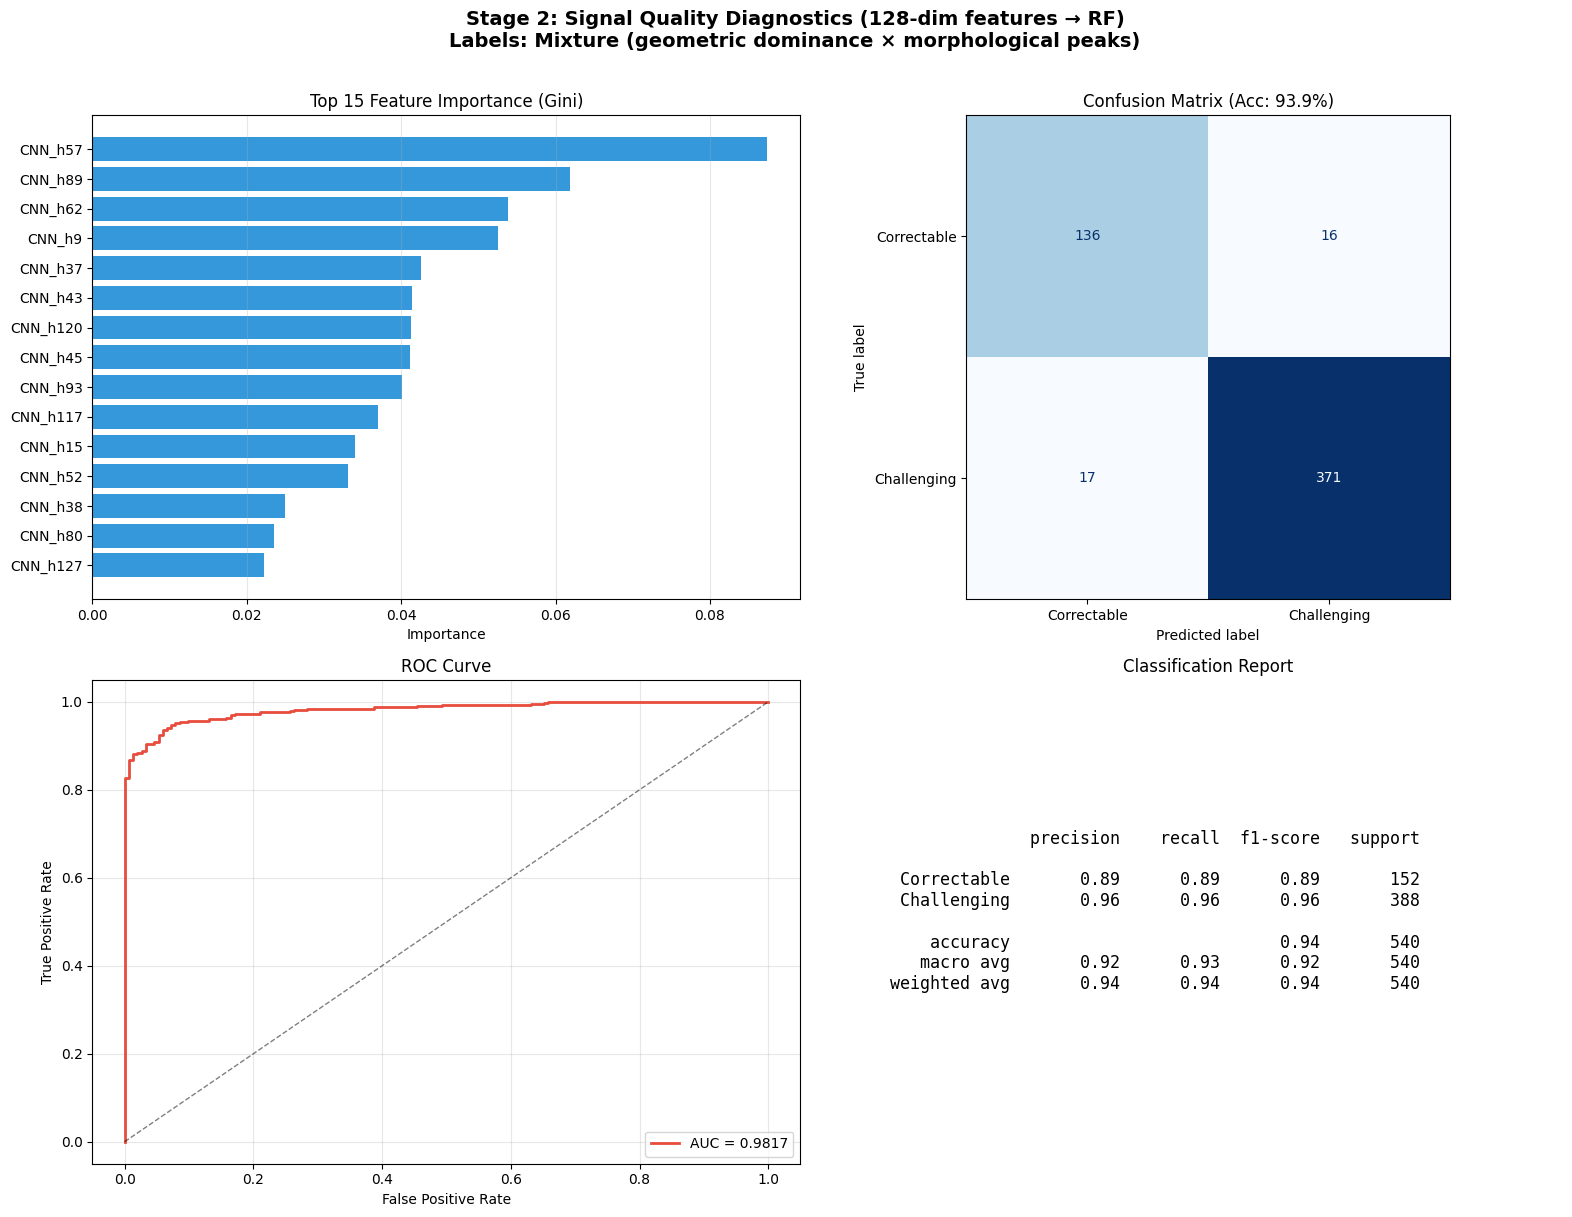


Top 15 Feature Importance (ranked):
  CNN_h57                   0.0874
  CNN_h89                   0.0619
  CNN_h62                   0.0539
  CNN_h9                    0.0526
  CNN_h37                   0.0426
  CNN_h43                   0.0415
  CNN_h120                  0.0413
  CNN_h45                   0.0411
  CNN_h93                   0.0402
  CNN_h117                  0.0370
  CNN_h15                   0.0340
  CNN_h52                   0.0331
  CNN_h38                   0.0250
  CNN_h80                   0.0235
  CNN_h127                  0.0222


In [21]:
# ==========================================
# DIAGNOSTICS
# ==========================================
y_pred_diag = rf_model.predict(X_test)

proba_diag = rf_model.predict_proba(X_test)
if proba_diag.shape[1] > 1:
    y_prob_diag = proba_diag[:, 1]
else:
    y_prob_diag = proba_diag[:, 0]

fig, axs = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# 1. Feature Importance (top 15 dims)
ax = axs[0, 0]
importances = rf_model.feature_importances_
top_k = min(15, len(importances))
sorted_idx = np.argsort(importances)[-top_k:]
ax.barh(np.array(FEATURE_NAMES)[sorted_idx], importances[sorted_idx], color='#3498db')
ax.set_title(f"Top {top_k} Feature Importance (Gini)")
ax.set_xlabel("Importance")
ax.grid(True, alpha=0.3, axis='x')

# 2. Confusion Matrix
ax = axs[0, 1]
cm = confusion_matrix(y_test, y_pred_diag)
disp = ConfusionMatrixDisplay(cm, display_labels=['Correctable', 'Challenging'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
acc = (y_test == y_pred_diag).mean()
ax.set_title(f"Confusion Matrix (Acc: {100*acc:.1f}%)")

# 3. ROC Curve
ax = axs[1, 0]
if len(np.unique(y_test)) > 1:
    fpr, tpr, _ = roc_curve(y_test, y_prob_diag)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_title("ROC Curve")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right')
else:
    ax.text(0.5, 0.5, 'Single class in test set', ha='center', va='center', fontsize=12)
    ax.set_title("ROC Curve (N/A)")
ax.grid(True, alpha=0.3)

# 4. Classification Report
ax = axs[1, 1]
report_text = classification_report(y_test, y_pred_diag,
                               target_names=['Correctable', 'Challenging'])
ax.text(0.05, 0.5, report_text, fontsize=12, fontfamily='monospace',
        verticalalignment='center', transform=ax.transAxes)
ax.set_title("Classification Report")
ax.axis('off')

plt.suptitle(f"Stage 2: Signal Quality Diagnostics ({FEATURE_DIM}-dim features → RF)\n"
             f"Labels: Mixture (geometric dominance × morphological peaks)",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print top features
print(f"\nTop 15 Feature Importance (ranked):")
for feat, imp in sorted(zip(FEATURE_NAMES, importances), key=lambda x: -x[1])[:15]:
    print(f"  {feat:<25} {imp:.4f}")

---
## 6b. Unseen Dataset Evaluation

Evaluate the trained RF on a **completely separate dataset** (`unseen_dataset.csv`) containing 2 NLOS scenarios (8.91m, 12.79m) never seen during training. This tests out-of-distribution generalization.

Loading: ../dataset/channels/unseen_dataset.csv
  Total samples: 2400, NLOS samples: 1200

  Mixture labeling (amplitude ratio >= 50% AND peaks <= 2):
    ──────────────────────────────────────────────────
    Correctable (clean bounce):     406 (33.8%)
    Challenging (multipath/noisy):   794 (66.2%)
    ──────────────────────────────────────────────────
    Bounce dominance stats — mean: 0.851, median: 1.000
    Peak count stats — mean: 3.91, max: 10
    Strongest peak power stats — mean: 18.6895, min: 5.9535, max: 49.7966

Unseen NLOS samples: 1200
  Correctable: 406, Challenging: 794
  Unseen embeddings shape: (1200, 128)

UNSEEN DATASET: CNN 128-dim → RF
Dataset: unseen_dataset.csv (1200 NLOS samples)
Overall Accuracy: 76.42%
ROC AUC:          0.8406

              precision    recall  f1-score   support

 Correctable       0.75      0.46      0.57       406
 Challenging       0.77      0.92      0.84       794

    accuracy                           0.76      1200
   macro avg   

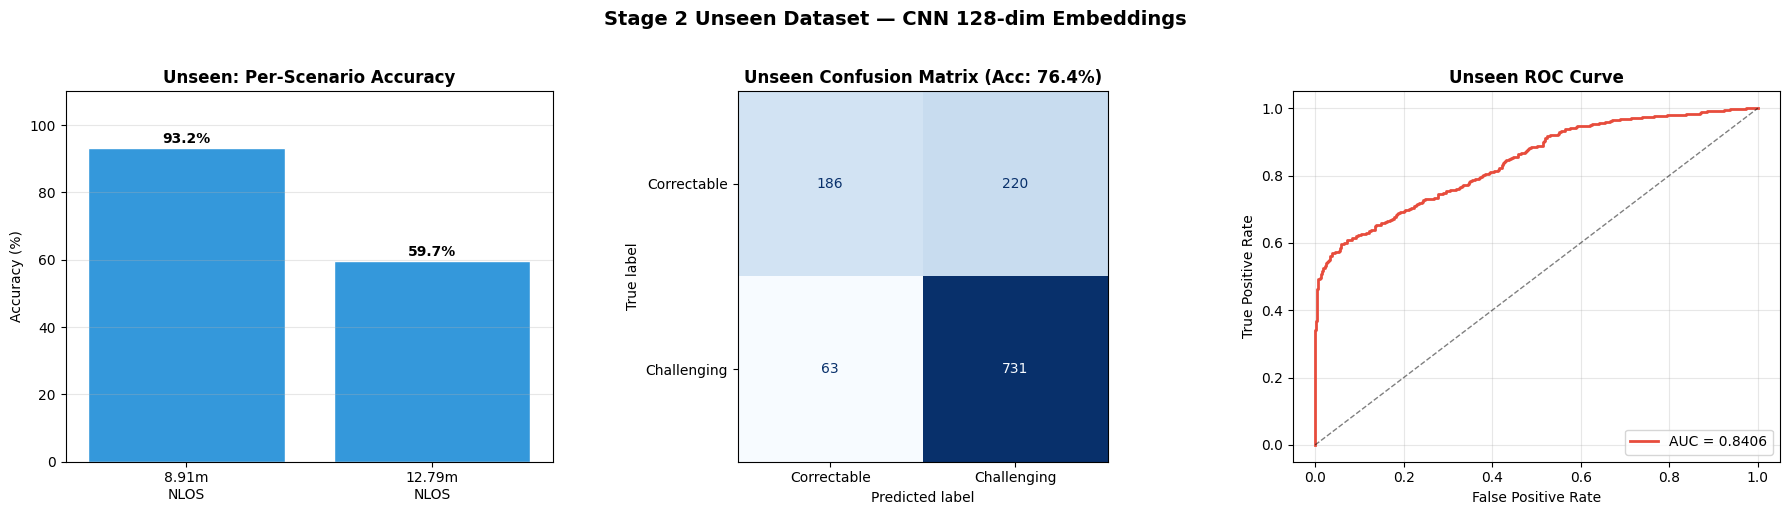

In [22]:
# ==========================================
# UNSEEN DATASET EVALUATION
# ==========================================
unseen_filepath = "../dataset/channels/unseen_dataset.csv"

# Load and process unseen NLOS data
(unseen_raw_sigs, unseen_leading_edges, unseen_nlos_df,
 unseen_labels, unseen_num_peaks, unseen_bounce_dom,
 unseen_spp) = load_nlos_features(unseen_filepath)

print(f"\nUnseen NLOS samples: {len(unseen_labels)}")
print(f"  Correctable: {int(np.sum(unseen_labels==0))}, Challenging: {int(np.sum(unseen_labels==1))}")

# Extract CNN embeddings for unseen data
unseen_cir_sequences = []
for i in range(len(unseen_raw_sigs)):
    crop = preprocess_cir_for_cnn(unseen_raw_sigs[i], unseen_leading_edges[i])
    unseen_cir_sequences.append(crop)

unseen_cir_tensor = torch.tensor(
    np.array(unseen_cir_sequences).reshape(-1, 1, STAGE1_CONFIG['total_len']),
    dtype=torch.float32
).to(device)

unseen_embeddings_list = []
with torch.no_grad():
    for i in range(0, len(unseen_cir_tensor), 256):
        batch_cir = unseen_cir_tensor[i:i+256]
        emb = cnn_encoder.embed(batch_cir)
        unseen_embeddings_list.append(emb.cpu().numpy())

unseen_embeddings = np.vstack(unseen_embeddings_list)
print(f"  Unseen embeddings shape: {unseen_embeddings.shape}")

# Predict with RF model
X_unseen = unseen_embeddings
y_unseen = unseen_labels

y_pred_unseen = rf_model.predict(X_unseen)
acc_unseen = (y_unseen == y_pred_unseen).mean()
report_unseen = classification_report(y_unseen, y_pred_unseen,
                                       target_names=['Correctable', 'Challenging'], output_dict=True)
proba_unseen = rf_model.predict_proba(X_unseen)
y_prob_unseen = proba_unseen[:, 1] if proba_unseen.shape[1] > 1 else proba_unseen[:, 0]
fpr_u, tpr_u, _ = roc_curve(y_unseen, y_prob_unseen)
auc_u = auc(fpr_u, tpr_u)

# Per-scenario accuracy (unseen)
unseen_scenarios = np.array([
    re.search(r'([\d.]+)m_nlos', str(sf)).group(1) + 'm'
    if re.search(r'([\d.]+)m_nlos', str(sf)) else 'unknown'
    for sf in unseen_nlos_df['Source_File'].values
])
unseen_unique_scenarios = sorted(set(unseen_scenarios), key=lambda x: float(x.replace('m', '')))

# Print results
print("\n" + "=" * 70)
print(f"UNSEEN DATASET: CNN {FEATURE_DIM}-dim → RF")
print("=" * 70)
print(f"Dataset: unseen_dataset.csv ({len(y_unseen)} NLOS samples)")
print(f"Overall Accuracy: {100*acc_unseen:.2f}%")
print(f"ROC AUC:          {auc_u:.4f}")
print()
print(classification_report(y_unseen, y_pred_unseen,
                             target_names=['Correctable', 'Challenging']))

print("Per-scenario accuracy (unseen):")
for sc in unseen_unique_scenarios:
    mask = unseen_scenarios == sc
    if mask.sum() > 0:
        sc_acc = (y_unseen[mask] == y_pred_unseen[mask]).mean()
        print(f"  {sc:>8s} NLOS: {100*sc_acc:.1f}% (n={mask.sum()})")

# Visualization
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.35)

# 1. Per-scenario accuracy bars
ax = axs[0]
scenario_accs_u = []
for sc in unseen_unique_scenarios:
    mask = unseen_scenarios == sc
    scenario_accs_u.append((y_unseen[mask] == y_pred_unseen[mask]).mean() if mask.sum() > 0 else 0)

x_sc = np.arange(len(unseen_unique_scenarios))
bars = ax.bar(x_sc, [100*v for v in scenario_accs_u], color='#3498db', edgecolor='white')
for bar, val in zip(bars, scenario_accs_u):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{100*val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x_sc)
ax.set_xticklabels([f'{s}\nNLOS' for s in unseen_unique_scenarios], fontsize=10)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Unseen: Per-Scenario Accuracy', fontsize=12, fontweight='bold')
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis='y')

# 2. Confusion matrix
ax = axs[1]
cm_u = confusion_matrix(y_unseen, y_pred_unseen)
disp = ConfusionMatrixDisplay(cm_u, display_labels=['Correctable', 'Challenging'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Unseen Confusion Matrix (Acc: {100*acc_unseen:.1f}%)', fontsize=12, fontweight='bold')

# 3. ROC curve
ax = axs[2]
ax.plot(fpr_u, tpr_u, color='#e74c3c', lw=2, label=f'AUC = {auc_u:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Unseen ROC Curve', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Stage 2 Unseen Dataset — CNN {FEATURE_DIM}-dim Embeddings',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 7: Save Artifacts

In [23]:
# ==========================================
# SAVE ARTIFACTS
# ==========================================
joblib.dump(rf_model, "stage2_bounce_rf.joblib")
print("Saved: stage2_bounce_rf.joblib")

joblib.dump({
    "config": CONFIG,
    "embedding_dim": EMBEDDING_DIM,
    "embedding_names": EMBEDDING_NAMES,
    "feature_dim": FEATURE_DIM,
    "feature_names": FEATURE_NAMES,
    "stage1_config": STAGE1_CONFIG,
    "encoder_class": "CNN_Classifier",
    "fp_conditioning": False,
    "label_strategy": "mixture_geometric_morphological",
    "dominance_type": "amplitude_ratio",
    "dominance_threshold": CONFIG["dominance_threshold"],
    "bounce_search_window": CONFIG["bounce_search_window"],
    "dominant_path_max_peaks": CONFIG["dominant_path_max_peaks"],
    "note": f"Mixture labels: Correctable if bounce amplitude ratio >= {CONFIG['dominance_threshold']:.0%} "
            f"AND num_peaks <= {CONFIG['dominant_path_max_peaks']}. "
            f"Dominance = bounce_peak_amp / strongest_peak_amp (not energy ratio). "
            f"Model input is {FEATURE_DIM}-dim CNN embeddings. "
            f"RF predicts signal quality from embeddings alone.",
}, "stage2_config.joblib")
print("Saved: stage2_config.joblib")

print(f"\nDependency: stage1_cnn_best.pt (frozen CNN_Classifier encoder)")
print(f"Feature dim: {FEATURE_DIM} (CNN embeddings only)")
print(f"Artifacts ready for Stage 3 pipeline.")

Saved: stage2_bounce_rf.joblib
Saved: stage2_config.joblib

Dependency: stage1_cnn_best.pt (frozen CNN_Classifier encoder)
Feature dim: 128 (CNN embeddings only)
Artifacts ready for Stage 3 pipeline.


## Summary

In [24]:
print("=" * 60)
print("Stage 2 — Summary")
print("=" * 60)
print(f"Model artifact: stage2_bounce_rf.joblib")
print(f"Config artifact: stage2_config.joblib")
print(f"Encoder dependency: stage1_cnn_best.pt (frozen CNN_Classifier)")
print()
print(f"Architecture: Frozen CNN_Classifier encoder → {FEATURE_DIM}-dim embeddings → RF classifier")
print(f"  CNN embeddings: {EMBEDDING_DIM}-dim (global average pooled Conv1d features)")
print()
print(f"Results:")
print(f"  70/30 split (test): Acc={100*test_acc:.2f}%, AUC={auc_test:.4f}")
print(f"  Unseen dataset:     Acc={100*acc_unseen:.2f}%, AUC={auc_u:.4f}")
print()
print(f"Labels: MIXTURE (geometric + morphological)")
print(f"  Criterion 1: bounce dominance >= {CONFIG['dominance_threshold']:.0%}")
print(f"  Criterion 2: num_peaks <= {CONFIG['dominant_path_max_peaks']}")
print(f"  Correctable (0): BOTH conditions met")
print(f"  Challenging (1): either condition violated")
print()
print("Pipeline: Stage 1 (CNN) → Stage 2 (CNN embeddings → RF → signal quality) → Stage 3 (ranging error)")

Stage 2 — Summary
Model artifact: stage2_bounce_rf.joblib
Config artifact: stage2_config.joblib
Encoder dependency: stage1_cnn_best.pt (frozen CNN_Classifier)

Architecture: Frozen CNN_Classifier encoder → 128-dim embeddings → RF classifier
  CNN embeddings: 128-dim (global average pooled Conv1d features)

Results:
  70/30 split (test): Acc=93.89%, AUC=0.9817
  Unseen dataset:     Acc=76.42%, AUC=0.8406

Labels: MIXTURE (geometric + morphological)
  Criterion 1: bounce dominance >= 50%
  Criterion 2: num_peaks <= 2
  Correctable (0): BOTH conditions met
  Challenging (1): either condition violated

Pipeline: Stage 1 (CNN) → Stage 2 (CNN embeddings → RF → signal quality) → Stage 3 (ranging error)
